In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader.data as web
import datetime

In [2]:
slug = "fed-decision-in-july-181"

url = f"https://gamma-api.polymarket.com/events?slug={slug}"
response = requests.get(url)
data = response.json()

print(json.dumps(data, indent=2))

[
  {
    "id": "287395",
    "ticker": "fed-decision-in-july-181",
    "slug": "fed-decision-in-july-181",
    "title": "Fed Decision in July?",
    "description": "The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal funds range are made by the Federal Open Market Committee (FOMC) meetings.\n\nThis market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's July 2026 meeting.\n\nIf the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 and will resolve to the relevant bracket. (e.g. if there's a cut/increase of 12.5 bps it will be considered to be 25 bps)\n\nThe resolution source for this market is the FOMC\u2019s statement after its meeting scheduled for July 28-29, 2026 according to the official calendar: h

In [3]:
event = data[0]

for market in event['markets']:
    print(market['groupItemTitle'])

50+ bps decrease
25 bps decrease
No change
25 bps increase
50+ bps increase


In [4]:
for market in event['markets']:
    if market['groupItemTitle'] == 'No change':
        target_market = market

In [5]:
condition_id = target_market['conditionId']
clob_token_ids = target_market['clobTokenIds']
clob_token_ids = json.loads(clob_token_ids)

print(condition_id)
print(clob_token_ids)

0x8bf1c1536ecb1c08fe13c6b71e8ab1f58bf3461c4cb79f5f1679f869a06aef86
['111604417349377875799825956621596386269673370070912696668140891647145772186047', '36015050921127306245266044699797268780268172446856063291868548314968920497494']


In [6]:
yes_token_id = clob_token_ids[0]

clob_url = "https://clob.polymarket.com/prices-history"
params = {
    "market": yes_token_id,
    "interval": "max",
    "fidelity": 1
}

response = requests.get(clob_url, params=params)
history = response.json()

print(history)

{'history': [{'t': 1784319007, 'p': 0.9435}, {'t': 1784319605, 'p': 0.9435}, {'t': 1784320208, 'p': 0.9435}, {'t': 1784320804, 'p': 0.9435}, {'t': 1784321405, 'p': 0.9435}, {'t': 1784322010, 'p': 0.9435}, {'t': 1784322606, 'p': 0.9445}, {'t': 1784323204, 'p': 0.9445}, {'t': 1784323809, 'p': 0.9445}, {'t': 1784324406, 'p': 0.9445}, {'t': 1784325005, 'p': 0.9445}, {'t': 1784325610, 'p': 0.9445}, {'t': 1784326209, 'p': 0.9445}, {'t': 1784326804, 'p': 0.9445}, {'t': 1784327408, 'p': 0.9445}, {'t': 1784328006, 'p': 0.9435}, {'t': 1784328606, 'p': 0.9435}, {'t': 1784329210, 'p': 0.9435}, {'t': 1784329805, 'p': 0.9435}, {'t': 1784330406, 'p': 0.9435}, {'t': 1784331010, 'p': 0.9435}, {'t': 1784331606, 'p': 0.9435}, {'t': 1784332206, 'p': 0.9435}, {'t': 1784332811, 'p': 0.9435}, {'t': 1784333405, 'p': 0.9435}, {'t': 1784334004, 'p': 0.9435}, {'t': 1784334608, 'p': 0.9435}, {'t': 1784335207, 'p': 0.9435}, {'t': 1784335806, 'p': 0.9435}, {'t': 1784336407, 'p': 0.9435}, {'t': 1784337005, 'p': 0.94

In [7]:
df = pd.DataFrame(history['history'])
df['datetime'] = pd.to_datetime(df['t'], unit='s')
df['datetime'] = df['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')
df.head()

,t,p,datetime
0,1784319007,0.9435,2026-07-17 16:10:07-04:00
1,1784319605,0.9435,2026-07-17 16:20:05-04:00
2,1784320208,0.9435,2026-07-17 16:30:08-04:00
3,1784320804,0.9435,2026-07-17 16:40:04-04:00
4,1784321405,0.9435,2026-07-17 16:50:05-04:00


In [8]:
window_df = df[(df['datetime'] >= '2026-07-29 12:00:00') & (df['datetime'] <= '2026-07-29 16:00:00')].copy()
window_df = window_df.rename(columns={'t': 'unix_timestamp', 'p': 'implied_probability_no_change'})
print(window_df.head())
print(window_df.tail())

      unix_timestamp  implied_probability_no_change                  datetime
1664      1785341444                         0.7245 2026-07-29 12:10:44-04:00
1665      1785342036                         0.7275 2026-07-29 12:20:36-04:00
1666      1785343235                         0.7405 2026-07-29 12:40:35-04:00
1667      1785343829                         0.7465 2026-07-29 12:50:29-04:00
1668      1785345038                         0.7425 2026-07-29 13:10:38-04:00
      unix_timestamp  implied_probability_no_change                  datetime
1678      1785352210                         0.9995 2026-07-29 15:10:10-04:00
1679      1785352812                         0.9995 2026-07-29 15:20:12-04:00
1680      1785353419                         0.9995 2026-07-29 15:30:19-04:00
1681      1785354012                         0.9995 2026-07-29 15:40:12-04:00
1682      1785354611                         0.9995 2026-07-29 15:50:11-04:00


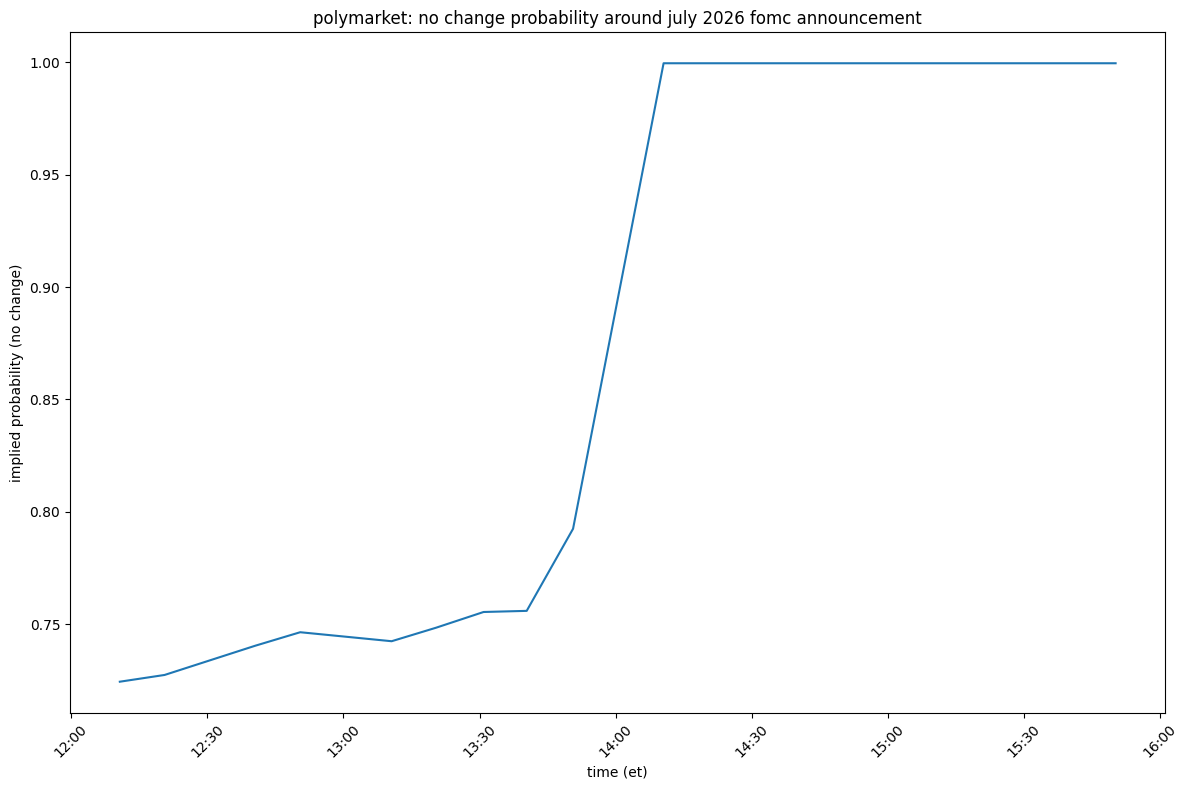

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(window_df['datetime'], window_df['implied_probability_no_change'])
ax.set_title('polymarket: no change probability around july 2026 fomc announcement')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied probability (no change)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=window_df['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
start = datetime.datetime(2026, 7, 1)
end = datetime.datetime(2026, 7, 28)

effr_full = web.DataReader('EFFR', 'fred', start, end)
r_before = effr_full['EFFR'].mean()

print(effr_full)
print(r_before)

            EFFR
DATE            
2026-07-01  3.63
2026-07-02  3.63
2026-07-03  3.63
2026-07-06  3.63
2026-07-07  3.63
2026-07-08  3.62
2026-07-09  3.62
2026-07-10  3.62
2026-07-13  3.62
2026-07-14  3.63
2026-07-15  3.63
2026-07-16  3.63
2026-07-17  3.63
2026-07-20  3.63
2026-07-21  3.63
2026-07-22  3.63
2026-07-23  3.63
2026-07-24  3.63
2026-07-27  3.63
2026-07-28  3.63
3.6279999999999992


In [11]:
all_probabilities = {}

for market in event['markets']:
    outcome_name = market['groupItemTitle']
    token_ids = json.loads(market['clobTokenIds'])
    yes_token_id_loop = token_ids[0]

    params = {
        "market": yes_token_id_loop,
        "interval": "max",
        "fidelity": 1
    }
    response = requests.get(clob_url, params=params)
    history_loop = response.json()

    outcome_df = pd.DataFrame(history_loop['history'])
    outcome_df['datetime'] = pd.to_datetime(outcome_df['t'], unit='s')
    outcome_df['datetime'] = outcome_df['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')

    all_probabilities[outcome_name] = outcome_df

print(all_probabilities.keys())

dict_keys(['50+ bps decrease', '25 bps decrease', 'No change', '25 bps increase', '50+ bps increase'])


In [12]:
windowed_outcomes = {}
for outcome_name, outcome_df in all_probabilities.items():
    windowed = outcome_df[(outcome_df['datetime'] >= '2026-07-29 12:00:00') & (outcome_df['datetime'] <= '2026-07-29 16:00:00')].copy()
    windowed_outcomes[outcome_name] = windowed

for name, wdf in windowed_outcomes.items():
    print(name, len(wdf), 'rows')

50+ bps decrease 24 rows
25 bps decrease 23 rows
No change 19 rows
25 bps increase 23 rows
50+ bps increase 19 rows


In [13]:
combined = pd.DataFrame()

for outcome_name, wdf in windowed_outcomes.items():
    s = wdf.set_index('datetime')['p'].resample('1min').last().ffill()
    combined[outcome_name] = s

combined = combined.dropna()
print(combined.head())
print(combined.tail())

                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
2026-07-29 12:10:00-04:00            0.0005           0.0025     0.7245   
2026-07-29 12:11:00-04:00            0.0005           0.0025     0.7245   
2026-07-29 12:12:00-04:00            0.0005           0.0025     0.7245   
2026-07-29 12:13:00-04:00            0.0005           0.0025     0.7245   
2026-07-29 12:14:00-04:00            0.0005           0.0025     0.7245   

                           25 bps increase  50+ bps increase  
datetime                                                      
2026-07-29 12:10:00-04:00           0.2665            0.0045  
2026-07-29 12:11:00-04:00           0.2665            0.0045  
2026-07-29 12:12:00-04:00           0.2665            0.0045  
2026-07-29 12:13:00-04:00           0.2665            0.0045  
2026-07-29 12:14:00-04:00           0.2665            0.0045  
                           50+ bp

In [19]:
prob_sum = (
    combined['50+ bps decrease'] +
    combined['25 bps decrease'] +
    combined['No change'] +
    combined['25 bps increase'] +
    combined['50+ bps increase']
)

combined['r_after'] = (
    (combined['50+ bps decrease'] / prob_sum) * (r_before - 0.50) +
    (combined['25 bps decrease'] / prob_sum) * (r_before - 0.25) +
    (combined['No change'] / prob_sum) * r_before +
    (combined['25 bps increase'] / prob_sum) * (r_before + 0.25) +
    (combined['50+ bps increase'] / prob_sum) * (r_before + 0.50)
)

print(combined[['r_after']].head())
print(combined[['r_after']].tail())

                            r_after
datetime                           
2026-07-29 12:10:00-04:00  3.696102
2026-07-29 12:11:00-04:00  3.696102
2026-07-29 12:12:00-04:00  3.696102
2026-07-29 12:13:00-04:00  3.696102
2026-07-29 12:14:00-04:00  3.696102
                           r_after
datetime                          
2026-07-29 15:46:00-04:00    3.628
2026-07-29 15:47:00-04:00    3.628
2026-07-29 15:48:00-04:00    3.628
2026-07-29 15:49:00-04:00    3.628
2026-07-29 15:50:00-04:00    3.628


In [15]:
zq_df = pd.read_csv('zq_july29.csv')
zq_df['datetime'] = pd.to_datetime(zq_df['time'], unit='s')
zq_df['datetime'] = zq_df['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')
print(zq_df.head())
print(zq_df.tail())

         time   open   high    low  close  Volume                  datetime
0  1783967820  96.27  96.27  96.27  96.27     481 2026-07-13 14:37:00-04:00
1  1783967880  96.27  96.27  96.27  96.27      11 2026-07-13 14:38:00-04:00
2  1783968060  96.27  96.27  96.27  96.27     640 2026-07-13 14:41:00-04:00
3  1783968120  96.27  96.27  96.27  96.27     199 2026-07-13 14:42:00-04:00
4  1783968180  96.27  96.27  96.27  96.27     139 2026-07-13 14:43:00-04:00
            time    open    high     low   close  Volume  \
6882  1786956780  96.335  96.335  96.335  96.335      17   
6883  1786957980  96.335  96.335  96.335  96.335      19   
6884  1786959120  96.335  96.335  96.335  96.335       2   
6885  1786959420  96.335  96.335  96.335  96.335     450   
6886  1786960140  96.335  96.335  96.335  96.335      41   

                      datetime  
6882 2026-08-17 04:53:00-04:00  
6883 2026-08-17 05:13:00-04:00  
6884 2026-08-17 05:32:00-04:00  
6885 2026-08-17 05:37:00-04:00  
6886 2026-08-17 05

In [16]:
zq_window = zq_df[(zq_df['datetime'] >= '2026-07-29 12:00:00') & (zq_df['datetime'] <= '2026-07-29 16:00:00')].copy()
print(zq_window.head())
print(zq_window.tail())

            time    open    high     low   close  Volume  \
4907  1785340800  96.285  96.285  96.285  96.285    1251   
4908  1785340860  96.285  96.285  96.285  96.285      57   
4909  1785340920  96.285  96.285  96.285  96.285     560   
4910  1785340980  96.285  96.285  96.285  96.285     261   
4911  1785341100  96.285  96.285  96.285  96.285      42   

                      datetime  
4907 2026-07-29 12:00:00-04:00  
4908 2026-07-29 12:01:00-04:00  
4909 2026-07-29 12:02:00-04:00  
4910 2026-07-29 12:03:00-04:00  
4911 2026-07-29 12:05:00-04:00  
            time    open    high     low   close  Volume  \
5111  1785354840  96.370  96.370  96.370  96.370       8   
5112  1785354900  96.365  96.365  96.365  96.365      31   
5113  1785354960  96.365  96.365  96.365  96.365      15   
5114  1785355080  96.365  96.365  96.365  96.365     243   
5115  1785355140  96.365  96.365  96.365  96.365      99   

                      datetime  
5111 2026-07-29 15:54:00-04:00  
5112 2026-07-2

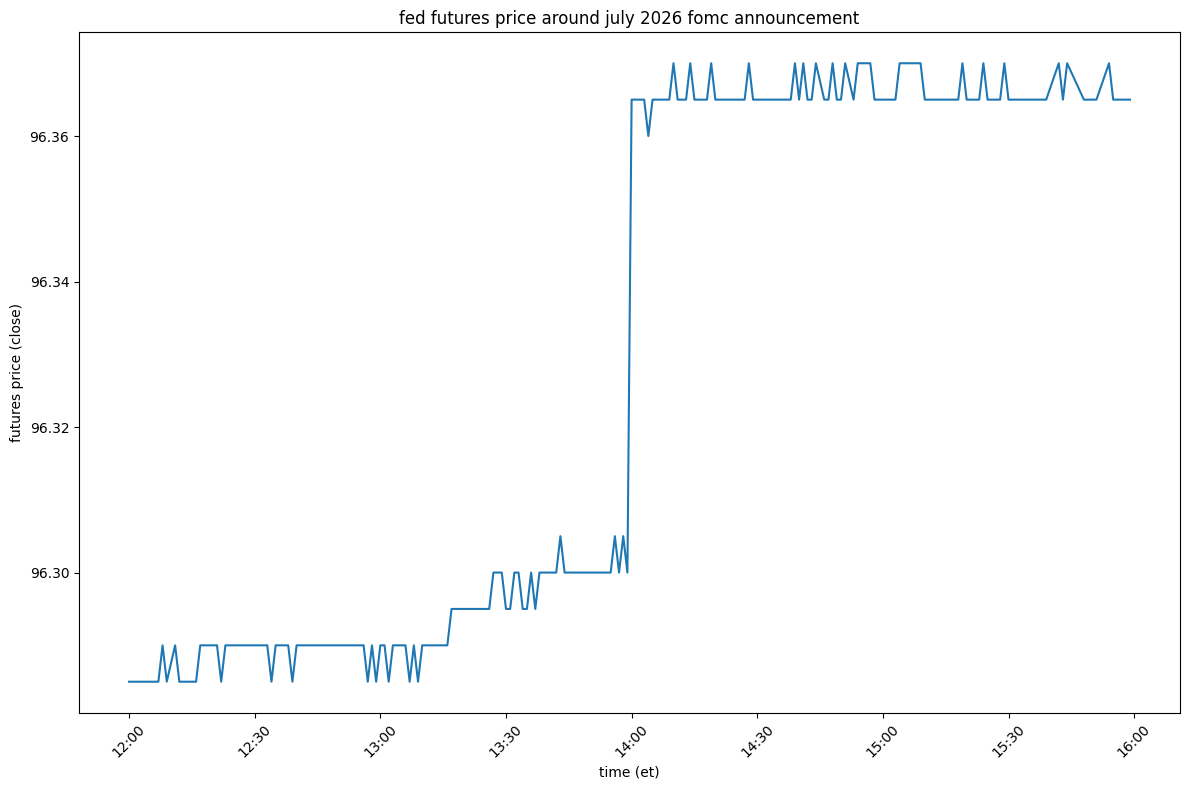

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(zq_window['datetime'], zq_window['close'])
ax.set_title('fed futures price around july 2026 fomc announcement')
ax.set_xlabel('time (et)')
ax.set_ylabel('futures price (close)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [18]:
zq_window['implied_rate'] = 100 - zq_window['close']
print(zq_window[['datetime', 'close', 'implied_rate']].head())
print(zq_window[['datetime', 'close', 'implied_rate']].tail())

                      datetime   close  implied_rate
4907 2026-07-29 12:00:00-04:00  96.285         3.715
4908 2026-07-29 12:01:00-04:00  96.285         3.715
4909 2026-07-29 12:02:00-04:00  96.285         3.715
4910 2026-07-29 12:03:00-04:00  96.285         3.715
4911 2026-07-29 12:05:00-04:00  96.285         3.715
                      datetime   close  implied_rate
5111 2026-07-29 15:54:00-04:00  96.370         3.630
5112 2026-07-29 15:55:00-04:00  96.365         3.635
5113 2026-07-29 15:56:00-04:00  96.365         3.635
5114 2026-07-29 15:58:00-04:00  96.365         3.635
5115 2026-07-29 15:59:00-04:00  96.365         3.635


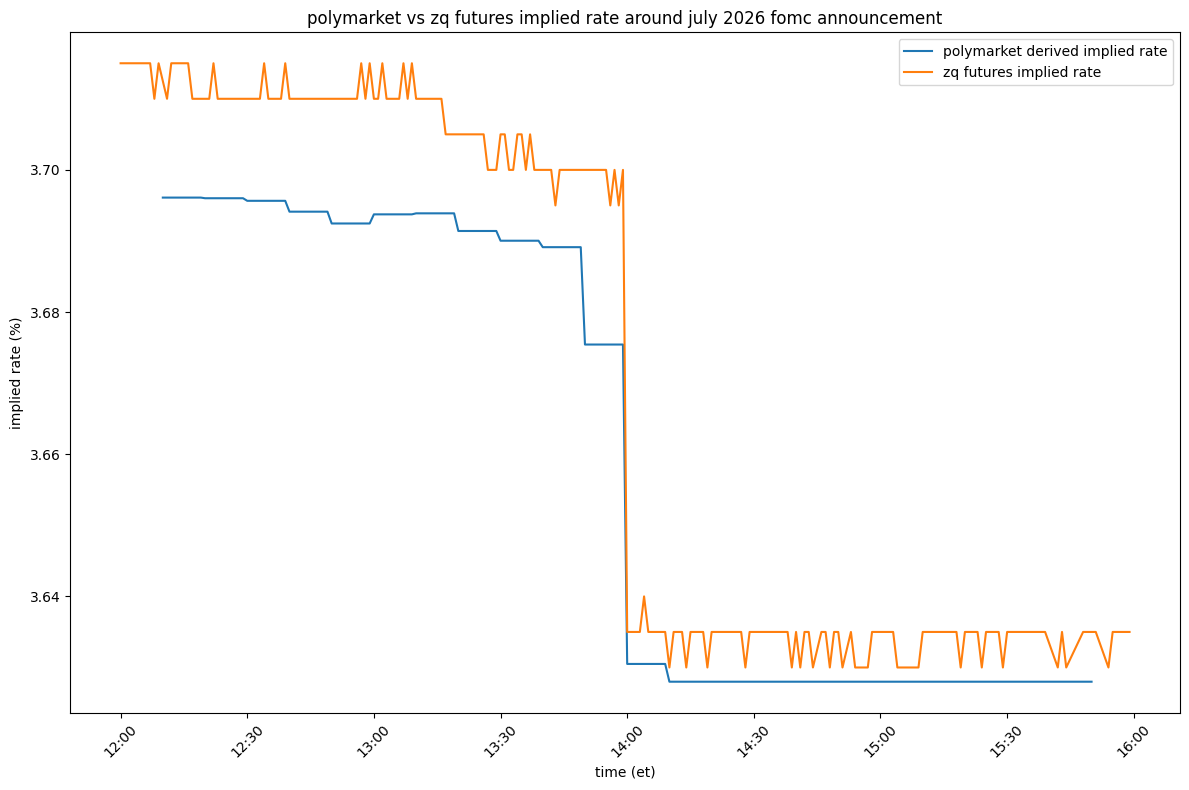

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(combined.index, combined['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_window['datetime'], zq_window['implied_rate'], label='zq futures implied rate', color='tab:orange')

ax.set_title('polymarket vs zq futures implied rate around july 2026 fomc announcement')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

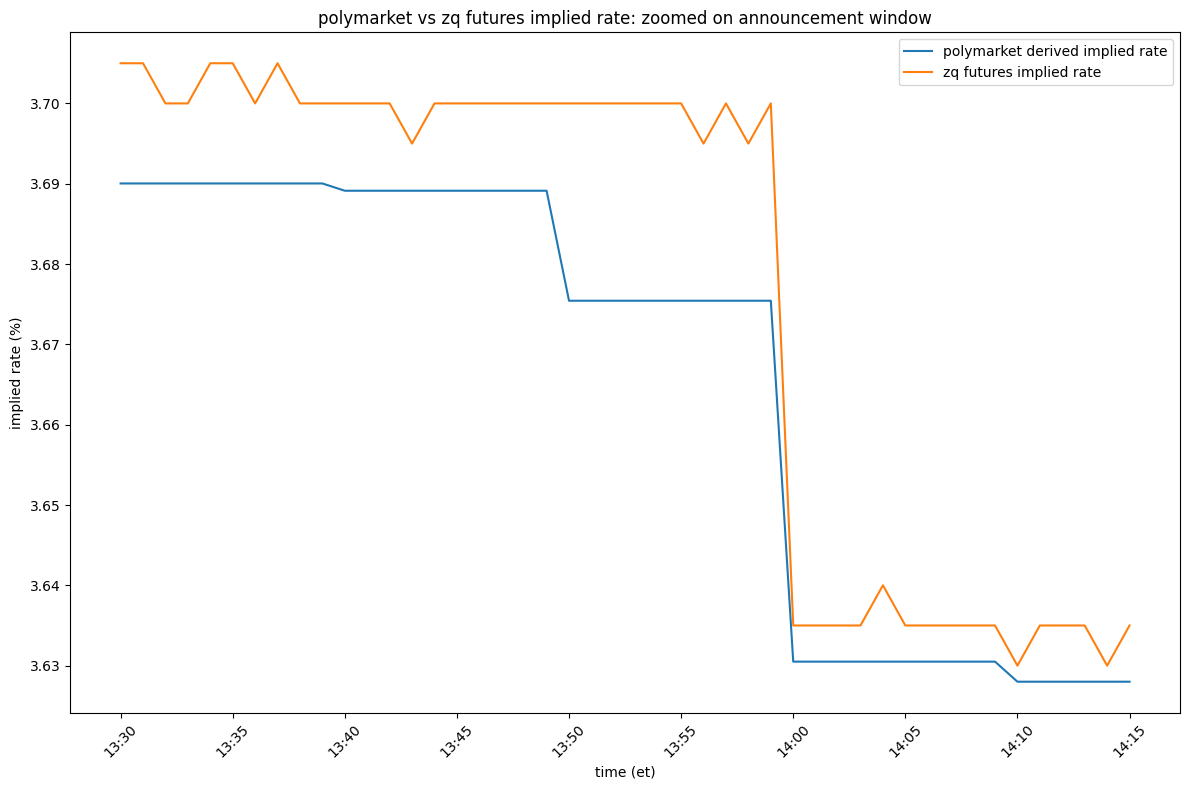

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

zoom_start = '2026-07-29 13:30:00'
zoom_end = '2026-07-29 14:15:00'

combined_zoom = combined[(combined.index >= zoom_start) & (combined.index <= zoom_end)]
zq_zoom = zq_window[(zq_window['datetime'] >= zoom_start) & (zq_window['datetime'] <= zoom_end)]

ax.plot(combined_zoom.index, combined_zoom['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_zoom['datetime'], zq_zoom['implied_rate'], label='zq futures implied rate', color='tab:orange')

ax.set_title('polymarket vs zq futures implied rate: zoomed on announcement window')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()